# Image segmentation with Keras

In [2]:
import math
import pathlib
import random
import re
from typing import Tuple

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tifffile import imread, imwrite

In [3]:
!nvidia-smi

Sun Jan 29 14:08:55 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 510.47.03    Driver Version: 510.47.03    CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   65C    P0    24W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [4]:
%%time
!rm -rf sample_data
!git clone https://github.com/mlambda/ign-FNF-2009.git

Cloning into 'ign-FNF-2009'...
remote: Enumerating objects: 4604, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4604 (delta 4), reused 8 (delta 2), pack-reused 4594
Receiving objects: 100% (4604/4604), 3.93 GiB | 33.95 MiB/s, done.
Resolving deltas: 100% (2894/2894), done.
Updating files: 100% (4869/4869), done.
CPU times: user 1.49 s, sys: 159 ms, total: 1.65 s
Wall time: 3min 5s


## Data

The data consists of 20 large map tiles from the IGN. Each large tile is itself a 3 × 3 square of 1024 × 1024 pixels.

2 tiles were set aside for validation, and 2 other tiles for testing.

In [5]:
df_train = pandas.read_csv("ign-FNF-2009/train-files.csv")
df_val = pandas.read_csv("ign-FNF-2009/val-files.csv")
df_test = pandas.read_csv("ign-FNF-2009/test-files.csv")

print("Training coordinates")
print(df_train.coord.unique())

print("Validation coordinates")
print(df_val.coord.unique())

print("Test coordinates")
print(df_test.coord.unique())

df_test

Training coordinates
['945_6845' '980_6825' '945_6925' '955_6915' '915_6825' '975_6850'
 '940_6905' '995_6895' '940_6925' '915_6890' '1015_6895' '920_6860'
 '890_6940' '975_6835' '975_6825' '925_6860']
Validation coordinates
['970_6845' '910_6935']
Test coordinates
['915_6915' '995_6850']


,Unnamed: 0,Observations,Annotations,latitude,longitude,ligne,colonne,coord
0,0,ign-FNF-2009/test/observations/915_6915_8_2_ob...,ign-FNF-2009/test/annotations/915_6915_8_2_0M5...,915,6915,8,2,915_6915
1,1,ign-FNF-2009/test/observations/995_6850_5_4_ob...,ign-FNF-2009/test/annotations/995_6850_5_4_0M5...,995,6850,5,4,995_6850
2,2,ign-FNF-2009/test/observations/915_6915_4_9_ob...,ign-FNF-2009/test/annotations/915_6915_4_9_0M5...,915,6915,4,9,915_6915
3,3,ign-FNF-2009/test/observations/915_6915_5_4_ob...,ign-FNF-2009/test/annotations/915_6915_5_4_0M5...,915,6915,5,4,915_6915
4,4,ign-FNF-2009/test/observations/995_6850_8_6_ob...,ign-FNF-2009/test/annotations/995_6850_8_6_0M5...,995,6850,8,6,995_6850
...,...,...,...,...,...,...,...,...
155,155,ign-FNF-2009/test/observations/995_6850_9_1_ob...,ign-FNF-2009/test/annotations/995_6850_9_1_0M5...,995,6850,9,1,995_6850
156,156,ign-FNF-2009/test/observations/995_6850_5_8_ob...,ign-FNF-2009/test/annotations/995_6850_5_8_0M5...,995,6850,5,8,995_6850
157,157,ign-FNF-2009/test/observations/995_6850_3_6_ob...,ign-FNF-2009/test/annotations/995_6850_3_6_0M5...,995,6850,3,6,995_6850
158,158,ign-FNF-2009/test/observations/995_6850_4_4_ob...,ign-FNF-2009/test/annotations/995_6850_4_4_0M5...,995,6850,4,4,995_6850


## Study of an example and its annotation

In [6]:
example_input = imread(df_train.Observations[0])
example_annotation = imread(df_train.Annotations[0])

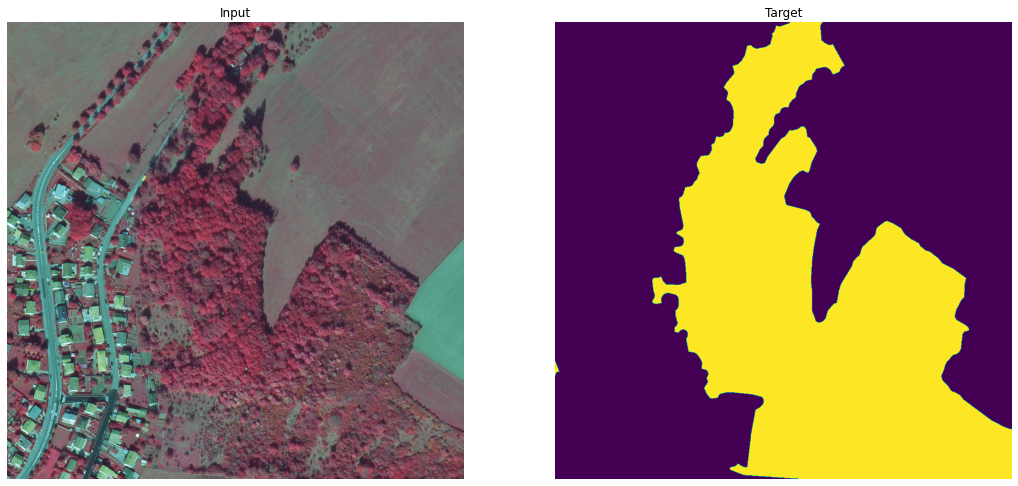

In [7]:
# Hack needed for imshow to correctly display tiles with only
# forest (otherwise the 1s representing the forest pixels are replaced by 0s
# if the tile consists only of 1s).
class NoopNormalize(matplotlib.colors.Normalize):
  def __init__(self, vmin=None, vmax=None, vcenter=None, clip=False):
    self.vmin = vmin
    self.vmax = vmax
    self.vcenter = vcenter
    self.clip = clip

  def __call__(self, value, clip=None):
    return value


_noop_normalize = NoopNormalize()


def display_sample(*images: numpy.array) -> None:
  """Show side-by-side an input image, the ground truth and the prediction."""
  figure, axes = plt.subplots(1, len(images), figsize=(18, 18))

  titles = ["Input", "Target", "Prediction"]
  for image, ax, title in zip(images, axes, titles):
    ax.set_title(title)
    if image.ndim == 2 or image.shape[2] == 3:
      ax.imshow(image, norm=_noop_normalize)
    elif image.shape[2] == 2:
      ax.imshow(image[..., 1], norm=_noop_normalize)
    elif image.shape[2] == 1:
      ax.imshow(image[..., 0], norm=_noop_normalize)
    ax.axis("off")
  plt.show()


display_sample(example_input, example_annotation)

## General options

In [8]:
# Original image size
dim_original = 1024

# Input size
dim_input = 512

# Number of image channel
num_channel = 3

## Data augmentation

In image processing, it is extremely important to augment the data with transforms to make the learned network less sensitive to rotations, cropping, etc. Implement the `transform_data` function, which, if `eval` is `True` will simply do a centred crop of the `X` and `Y` images, and otherwise do whatever transformations you deem appropriate on these same arrays for training (random cropping, mirroring, rotation, colour noise, brightness, etc).

To do this, use the functions in the [`tf.image`] module (https://www.tensorflow.org/api_docs/python/tf/image/).

In [9]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: Tuple[int, int] = (dim_input, dim_input),
) -> Tuple[numpy.ndarray, numpy.ndarray]:
  # Votre code ici
  return X, Y


# display_sample(*transform_data(example_input, example_annotation))

### Solution

In [10]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: Tuple[int, int] = (dim_input, dim_input),
) -> Tuple[numpy.ndarray, numpy.ndarray]:
  height, width = X.shape[:2]
  cropped_height, cropped_width = cropped_size
  if eval:
    # Centered cropping
    crop_params = dict(
      offset_height=(height - cropped_height) // 2,
      offset_width=(width - cropped_width) // 2,
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)
  else:
    # Random Rotation
    k = random.choice([None, 1, 3])
    if k is not None:
      X = tf.image.rot90(X, k)
      Y = tf.image.rot90(Y, k)

    # Random cropping
    crop_params = dict(
      offset_height=random.randint(0, height - cropped_height),
      offset_width=random.randint(0, width - cropped_width),
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)

    # Horizontal mirror
    if random.random() > 0.5:
      X = tf.image.flip_left_right(X)
      Y = tf.image.flip_left_right(Y)

    # Vertical mirror
    if random.random() > 0.5:
      X = tf.image.flip_up_down(X)
      Y = tf.image.flip_up_down(Y)
  return X, Y


for _ in range(10):
  display_sample(*transform_data(example_input, example_annotation))

Output hidden; open in https://colab.research.google.com to view.

## Creating a Keras generator

To define a Keras generator, we will use the class [`keras.utils.Sequence`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/Sequence). To do this, we need two main methods: `__getitem__`, which is called at each iteration to retrieve the batch to be processed, and `__len__`, which is called to find out the total number of batches that will be supplied by the generator. We will also use `on_epoch_end` to shuffle the dataset before the next iteration.

In [11]:
class DataGenerator(keras.utils.Sequence):
  """Generate data in batches with appropriate transforms."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: Tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    pass  # Votre code ici

  def __len__(self):
    """Compute the number of batches per epoch."""
    pass  # Votre code ici

  def __getitem__(self, index):
    """Generate one batch of data."""
    pass  # Votre code ici

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    pass  # Votre code ici

### Solution

In [12]:
class DataGenerator(keras.utils.Sequence):
  """Generate data for Keras."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: Tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    self.X_paths = df.Observations
    self.Y_paths = df.Annotations
    assert self.X_paths.shape[0] == self.Y_paths.shape[0]
    self.batch_size = batch_size
    self.eval = eval
    self.cropped_size = cropped_size
    if eval:
      self.indices = numpy.arange(self.X_paths.shape[0])
    else:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])

  def __len__(self):
    """Compute the number of batches per epoch."""
    return int(math.ceil(self.X_paths.shape[0] / self.batch_size))

  def __getitem__(self, index):
    """Generate one batch of data."""
    # Generate indexes of the batch
    start = index * self.batch_size
    Xs = []
    Ys = []
    for i in self.indices[start : start + self.batch_size]:
      X, Y = transform_data(
        imread(self.X_paths[i]),
        imread(self.Y_paths[i]).argmax(axis=-1)[..., numpy.newaxis],
        self.eval,
        self.cropped_size,
      )
      Xs.append(X)
      Ys.append(tf.squeeze(Y))
    return tf.stack(Xs), tf.stack(Ys)

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    if not self.eval:
      self.indices = numpy.arange(self.X_paths.shape[0])


generator = DataGenerator(df_train, 3, True)
X, Y = generator[0]
X.shape, Y.shape

(TensorShape([3, 512, 512, 3]), TensorShape([3, 512, 512]))

## Creating the model

For the model, we need to go from an image of dimension (batch × height × width × 3) to an output of dimension (batch × height × width).

You can take inspiration from the architecture seen in the demonstration of the autoencoders. This time, however, we will not reduce the capacity of the network at the centre of the model.

You can also see [this Keras code example page](https://keras.io/examples/vision/oxford_pets_image_segmentation/#prepare-unet-xceptionstyle-model) for more information.

In [13]:
def get_model(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  pass  # your code here

### Solution

In [14]:
# Implementation of the U-net model as described on the page
# https://paperswithcode.com/method/u-net
# You can also implement any other suitable template:
# https://paperswithcode.com/methods/category/segmentation-models


def downsample(inputs):
  return keras.layers.MaxPooling2D(pool_size=(2, 2))(inputs)


def upsample(inputs):
  return keras.layers.UpSampling2D(size=(2, 2))(inputs)


def semiblock(inputs, feature_maps):
  conv = keras.layers.Conv2D(feature_maps, 3, activation="relu", padding="same")(inputs)
  batch_norm = keras.layers.BatchNormalization()(conv)
  relu = keras.layers.ReLU()(batch_norm)
  dropout = keras.layers.Dropout(0.1)(relu)
  return dropout


def block(inputs, feature_maps):
  return semiblock(semiblock(inputs, feature_maps), feature_maps)


def concat(*layers):
  return keras.layers.Concatenate()(layers)


def get_model(starting_depth=32, steps=5):
  inputs = keras.layers.Input((dim_input, dim_input, num_channel))
  encodings = []
  depths = [min(512, starting_depth * 2**i) for i in range(steps)]
  for depth in depths:
    encodings.append(block(downsample(encodings[-1]) if encodings else inputs, depth))
  x = encodings[-1]
  for depth, encoding in zip(depths[-2::-1], encodings[-2::-1]):
    print(upsample(x), encoding)
    x = block(concat(encoding, upsample(x)), depth)
  outputs = keras.layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)

  model = keras.Model(inputs=inputs, outputs=outputs)

  return model

## Training

We can now use our data generation class to train our model.


In [15]:
# your code here

### Solution

In [16]:
# Model creation
model = get_model()
model.summary()
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

batch_size = 4

# Data generator creation
train_generator = DataGenerator(df_train, batch_size, eval=False)
val_generator = DataGenerator(df_val, batch_size, eval=True)

# Training the model, evaluating it on the validation generator at the end
# of each epoch
epochs = 15
model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=epochs,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

KerasTensor(type_spec=TensorSpec(shape=(None, 64, 64, 512), dtype=tf.float32, name=None), name='up_sampling2d/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d'") KerasTensor(type_spec=TensorSpec(shape=(None, 64, 64, 256), dtype=tf.float32, name=None), name='dropout_7/Identity:0', description="created by layer 'dropout_7'")
KerasTensor(type_spec=TensorSpec(shape=(None, 128, 128, 256), dtype=tf.float32, name=None), name='up_sampling2d_2/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d_2'") KerasTensor(type_spec=TensorSpec(shape=(None, 128, 128, 128), dtype=tf.float32, name=None), name='dropout_5/Identity:0', description="created by layer 'dropout_5'")
KerasTensor(type_spec=TensorSpec(shape=(None, 256, 256, 128), dtype=tf.float32, name=None), name='up_sampling2d_4/resize/ResizeNearestNeighbor:0', description="created by layer 'up_sampling2d_4'") KerasTensor(type_spec=TensorSpec(shape=(None, 256, 256, 64), dtype=tf.float32, name=Non

## Applying to test data

Once you have learned your model sufficiently, apply it to the test data: are the predictions of good quality?

In [17]:
# your model here

### Solution

In [18]:
# Load best model
model.load_weights("best_model.h5")

test_generator = DataGenerator(df_test, 24, eval=True)
X, Y = test_generator[2]
model.evaluate(test_generator, batch_size=4)
preds = model.predict(X)[..., 0]

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

Output hidden; open in https://colab.research.google.com to view.

## Pretrained model

In [19]:
base_model = keras.applications.EfficientNetB7(
  include_top=False,
  weights="imagenet",
  input_shape=(dim_input, dim_input, num_channel),
)

base_model.trainable = False

model = keras.Sequential(
  [  # (16, 16, 2560)
    base_model,
    # your code here
  ]
)

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

model.summary()

# model.fit(train_generator,
#           validation_data=val_generator,
#           epochs=epochs,
#           callbacks=[keras.callbacks.EarlyStopping(patience=5,
#                                                    monitor="val_loss"),
#                      keras.callbacks.ModelCheckpoint(
#                          filepath="best_model_b7.h5",
#                          monitor="val_accuracy",
#                          mode="max",
#                          save_weights_only=True,
#                          save_best_only=True,)])

258076736/258076736 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb7 (Functional)  (None, 16, 16, 2560)     64097687  
                                                                 
Total params: 64,097,687
Trainable params: 0
Non-trainable params: 64,097,687
_________________________________________________________________


### Solution

In [20]:
base_model = keras.applications.EfficientNetB7(
  include_top=False,
  weights="imagenet",
  input_shape=(dim_input, dim_input, num_channel),
)

base_model.trainable = False

starting_depth = 512

conv_params = dict(kernel_size=3, padding="same", activation="relu")

model = keras.Sequential(
  [  # (16, 16, 2560)
    base_model,
    # (16, 16, 512)
    keras.layers.Conv2D(starting_depth, 1, activation="relu"),
    # (32, 32, 512)
    keras.layers.UpSampling2D(),
    # (32, 32, 256)
    keras.layers.Conv2D(starting_depth // 2, **conv_params),
    # (64, 64, 256)
    keras.layers.UpSampling2D(),
    # (64, 64, 128)
    keras.layers.Conv2D(starting_depth // 4, **conv_params),
    # (128, 128, 128)
    keras.layers.UpSampling2D(),
    # (128, 128, 64)
    keras.layers.Conv2D(starting_depth // 8, **conv_params),
    # (256, 256, 64)
    keras.layers.UpSampling2D(),
    # (256, 256, 32)
    keras.layers.Conv2D(starting_depth // 16, **conv_params),
    # (512, 512, 32)
    keras.layers.UpSampling2D(),
    # (512, 512, 16)
    keras.layers.Conv2D(starting_depth // 32, **conv_params),
    keras.layers.Dropout(0.9),
    # (512, 512, 1)
    keras.layers.Conv2D(1, 3, padding="same", activation="sigmoid"),
  ]
)

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

model.summary()

model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=epochs,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model_b7.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb7 (Functional)  (None, 16, 16, 2560)     64097687  
                                                                 
 conv2d_19 (Conv2D)          (None, 16, 16, 512)       1311232   
                                                                 
 up_sampling2d_8 (UpSampling  (None, 32, 32, 512)      0         
 2D)                                                             
                                                                 
 conv2d_20 (Conv2D)          (None, 32, 32, 256)       1179904   
                                                                 
 up_sampling2d_9 (UpSampling  (None, 64, 64, 256)      0         
 2D)                                                             
                                                                 
 conv2d_21 (Conv2D)          (None, 64, 64, 128)      

In [21]:
# Load best model
model.load_weights("best_model_b7.h5")


test_generator = DataGenerator(df_test, 24, eval=True)
X, Y = test_generator[2]
model.evaluate(test_generator, batch_size=4)
preds = model.predict(X)[..., 0]

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

Output hidden; open in https://colab.research.google.com to view.